# Adaptive Recursive RAG — ML Rigorous Version (Final)

This notebook implements and benchmarks three RAG architectures on HotpotQA multi-hop questions.
It contains the 5 major research upgrades, the 8 peer-review ML fixes, AND the final **Evaluation Parity** fixes.



## 1. Setup & Imports

In [1]:
%pip install -q \
transformers==4.41.2 \
accelerate==0.30.1 \
bitsandbytes \
sentence-transformers==2.7.0 \
faiss-cpu \
datasets \
pandas \
matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 70.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.8 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

import re
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
from collections import Counter
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print("All imports OK.")

All imports OK.


## 2. Dataset Loading & Corpus Construction

In [3]:
print("Loading HotpotQA (distractor) validation split, sample 75...")
dataset = load_dataset("hotpot_qa", "distractor", split="validation")
sample = dataset.select(range(75))

print("Constructing corpus with deduplication...")
all_passages = []
seen = set()

for example in sample:
    titles = example["context"]["title"]
    sentences_list = example["context"]["sentences"]
    for title, sentences in zip(titles, sentences_list):
        passage = title + ". " + " ".join(sentences)
        if passage not in seen:
            seen.add(passage)
            all_passages.append(passage)

print(f"Sample size: {len(sample)} questions.")
print(f"Corpus size: {len(all_passages)} unique passages.")

Loading HotpotQA (distractor) validation split, sample 75...


README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Constructing corpus with deduplication...
Sample size: 75 questions.
Corpus size: 741 unique passages.


## 3. FAISS Index Construction

In [4]:
print("Loading BGE-small embedding model...")
embed_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

print("Encoding corpus...")
passage_embeddings = embed_model.encode(
    all_passages, batch_size=64, show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")

dim = passage_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # inner product == cosine for L2-normalised vecs
index.add(passage_embeddings)
print(f"FAISS index ready: {index.ntotal} vectors, dim={dim}")

passage_emb_cache = {
    passage: passage_embeddings[i]
    for i, passage in enumerate(all_passages)
}
print(f"Embedding cache built: {len(passage_emb_cache)} entries.")

def _get_embeddings(texts):
    cached   = [passage_emb_cache.get(t) for t in texts]
    miss_idx = [i for i, e in enumerate(cached) if e is None]
    if miss_idx:
        miss_embs = embed_model.encode(
            [texts[i] for i in miss_idx], normalize_embeddings=True
        )
        for j, i in enumerate(miss_idx):
            cached[i] = miss_embs[j]
    return np.array(cached, dtype="float32")


Loading BGE-small embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

FAISS index ready: 741 vectors, dim=384
Embedding cache built: 741 entries.


## 4. Language Model Loading (Phi-3 Mini 4-bit)

In [5]:
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print(f"Loading {MODEL_ID} with 4-bit quantization...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print("Model ready.")

Loading microsoft/Phi-3-mini-4k-instruct with 4-bit quantization...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Model ready.


## 5. NLI Verifier Loading

In [6]:
print("Loading NLI verifier (cross-encoder/nli-deberta-v3-small)...")
nli_verifier = CrossEncoder(
    "cross-encoder/nli-deberta-v3-small",
    max_length=512,
    num_labels=3,
)
print("NLI verifier ready.")

import math as _math

NLI_CONTRADICTION = 0
NLI_NEUTRAL       = 1
NLI_ENTAILMENT    = 2
NLI_ENTAIL_THRESHOLD = 0.30

def _softmax3(logits):
    m = max(logits)
    e = [_math.exp(x - m) for x in logits]
    s = sum(e)
    return [v / s for v in e]

def nli_verify_claims(claims, docs):
    if not claims or not docs:
        n = len(claims)
        return {"supported": [False]*n, "labels": ["neutral"]*n,
                "scores": [0.0]*n, "contradiction_flags": [False]*n}

    claim_embs = embed_model.encode(claims, normalize_embeddings=True)
    doc_embs   = embed_model.encode(
        [d[:500] for d in docs], normalize_embeddings=True
    )
    sim = claim_embs @ doc_embs.T

    supported, labels, scores, contra_flags = [], [], [], []
    for ci, claim in enumerate(claims):
        top_doc_idxs = np.argsort(sim[ci])[::-1][:2]
        top_docs = [docs[j] for j in top_doc_idxs]
        pairs = [(claim, doc[:800]) for doc in top_docs]
        raw   = nli_verifier.predict(pairs, apply_softmax=False)

        best_entail, best_label, best_contra = 0.0, "neutral", False
        for logits in raw:
            probs = _softmax3(list(logits))
            ep    = probs[NLI_ENTAILMENT]
            top_i = probs.index(max(probs))
            if ep > best_entail:
                best_entail = ep
                best_label  = (
                    "entails" if top_i == NLI_ENTAILMENT else
                    "contradicts" if top_i == NLI_CONTRADICTION else "neutral"
                )
                best_contra = (top_i == NLI_CONTRADICTION)

        supported.append(best_entail >= NLI_ENTAIL_THRESHOLD)
        labels.append(best_label)
        scores.append(round(best_entail, 4))
        contra_flags.append(best_contra)

    return {"supported": supported, "labels": labels,
            "scores": scores, "contradiction_flags": contra_flags}


Loading NLI verifier (cross-encoder/nli-deberta-v3-small)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

NLI verifier ready.


## 6. Core Functions

In [7]:
_llm_call_count = 0

def reset_llm_counter():
    global _llm_call_count
    _llm_call_count = 0

def get_llm_count():
    return _llm_call_count

def retrieve(query: str, existing_docs: list[str], k: int = 8) -> list[str]:
    q_emb = embed_model.encode(
        [query], normalize_embeddings=True
    ).astype("float32")
    _, indices = index.search(q_emb, k)
    existing_set = set(existing_docs)
    new_docs = [
        all_passages[i] for i in indices[0]
        if 0 <= i < len(all_passages) and all_passages[i] not in existing_set
    ]
    return existing_docs + new_docs

In [8]:
DIVERSITY_THRESHOLD = 0.15
K_CONTEXT_KEEP      = 6

def compute_retrieval_diversity(docs):
    if len(docs) < 2:
        return 1.0
    embs = embed_model.encode(docs[:10], normalize_embeddings=True)
    sim  = embs @ embs.T
    n    = len(embs)
    off  = [sim[i, j] for i in range(n) for j in range(n) if i != j]
    return 1.0 - float(np.mean(off))

def prune_context(docs, claims, k=K_CONTEXT_KEEP, query=""):
    if len(docs) <= k:
        return docs

    anchor_text = " ".join(claims)[:300] if claims else query[:300]
    if not anchor_text:
        return docs[:k]

    pairs  = [(anchor_text, doc[:800]) for doc in docs]
    raw    = nli_verifier.predict(pairs, apply_softmax=False)

    scores = []
    for logits in raw:
        probs = _softmax3(list(logits))
        scores.append(probs[NLI_ENTAILMENT])

    ranked = sorted(zip(scores, docs), key=lambda x: -x[0])
    return [doc for _, doc in ranked[:k]]

from math import log as _log
def _build_idf(passages):
    df = Counter()
    for p in passages:
        toks = set(re.findall(r"[A-Za-z]{3,}", p.lower()))
        df.update(toks)
    N = len(passages)
    return {tok: _log((N + 1) / (cnt + 1)) for tok, cnt in df.items()}

_corpus_idf = _build_idf(all_passages)

def build_keyword_expansion_query(original_query, failed_claims):
    stopwords = {"this", "that", "with", "from", "they", "their", "were",
                 "have", "been", "also", "some", "what", "when", "which",
                 "there", "other", "about", "into", "more", "than"}
    words = []
    for claim in failed_claims:
        long_tokens = re.findall(r"[A-Za-z]{5,}", claim)
        words.extend([t.lower() for t in long_tokens if t.lower() not in stopwords])
        short_caps = re.findall(r"\b[A-Z][A-Za-z]{2,3}\b", claim)
        words.extend([t for t in short_caps if t.lower() not in stopwords])

    if not words:
        return original_query

    scored = sorted(set(words), key=lambda w: -_corpus_idf.get(w, 0))
    kws = scored[:4]
    return original_query + " " + " ".join(kws)


In [9]:
def decompose_query(query):
    global _llm_call_count
    _llm_call_count += 1

    prompt = (
        "<|user|>\n"
        "A multi-hop question requires finding intermediate facts to reach the final answer.\n"
        "Break the question below into 2 or 3 ordered sub-questions, one per line.\n"
        "Each sub-question should be answerable from a single Wikipedia passage.\n"
        "Output ONLY the numbered sub-questions (1. 2. 3.) with no extra explanation.\n\n"
        f"Question: {query}\n"
        "<|end|>\n<|assistant|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=120, do_sample=False,
            temperature=1.0, pad_token_id=tokenizer.eos_token_id,
        )
    generated = output[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True).strip()

    lines = re.findall(r"\d+\.\s*(.+)", text)
    sub_qs = [l.strip() for l in lines if len(l.strip()) > 5]
    return sub_qs[:3] if len(sub_qs) >= 2 else [query]

def retrieve_multihop(query, existing_docs, sub_queries=None, k_per_hop=5):
    if sub_queries is None or len(sub_queries) < 2:
        return retrieve(query, existing_docs, k=k_per_hop * 2)

    all_docs = list(existing_docs)
    seen     = set(existing_docs)
    for sq in sub_queries:
        q_emb = embed_model.encode([sq], normalize_embeddings=True).astype("float32")
        _, idxs = index.search(q_emb, k_per_hop)
        for i in idxs[0]:
            if 0 <= i < len(all_passages):
                p = all_passages[i]
                if p not in seen:
                    seen.add(p)
                    all_docs.append(p)
    return all_docs


In [10]:
def detect_question_type(query):
    yn_patterns = [
        r"^(is|are|was|were|do|does|did|can|could|will|would|should|has|have|had)\b",
        r"^(isn't|aren't|wasn't|weren't|don't|doesn't|didn't)\b",
    ]
    query_lower = query.strip().lower()
    for p in yn_patterns:
        if re.match(p, query_lower):
            return "yesno"
    return "open"

def _build_prompt(numbered_docs: str, query: str, mode: str, reasoning: str = "") -> str:
    grounding = (
        "Use the documents below to answer the question. "
        "Your answer must be supported by or directly inferable from the provided documents. "
        "You may combine facts across multiple documents to reach a conclusion. "
        "Do NOT add information that cannot be supported by the documents. "
        "If the answer truly cannot be determined from the documents, say: I don't know."
    )
    qtype = detect_question_type(query)
    if mode in ("adaptive_pass1", "standard", "recursive"):
        # UNIFIED GENERATION: All modes now use the exact same strict extraction formatting.
        yn_hint = "This is a yes/no question. After your reasoning, your FINAL_ANSWER must be exactly 'yes' or 'no'. " if qtype == "yesno" else ""
        return (
            f"<|user|>\n{grounding}\n\n"
            f"Documents:\n{numbered_docs}\n\n"
            f"Question: {query}\n\n"
            f"{yn_hint}"
            f"Think step-by-step through the documents to find the answer. "
            f"End your response with exactly: FINAL_ANSWER: <your concise answer><|end|>\n"
            f"<|assistant|>\n"
        )
    elif mode == "adaptive_pass2":
        yn_constraint = "This is a yes/no question. You MUST answer with ONLY: ANSWER: yes  or  ANSWER: no\\n" if qtype == "yesno" else ""
        return (
            f"<|user|>\n"
            f"Based on the reasoning below, give a single concise factual answer "
            f"to the question. Begin your answer with ANSWER: followed by ONLY the answer — "
            f"no explanation, no preamble, no reasoning steps. "
            f"{yn_constraint}"
            f"Question: {query}\n\n"
            f"Reasoning:\n{reasoning}\n\n"
            f"Concise answer (begin with ANSWER:):<|end|>\n"
            f"<|assistant|>\n"
        )
    return ""

def _llm_call(prompt: str, max_new_tokens: int) -> str:
    global _llm_call_count
    _llm_call_count += 1
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=3072).to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            temperature=1.0, pad_token_id=tokenizer.eos_token_id,
        )
    generated = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

def generate(query: str, docs: list[str], max_new_tokens: int = 300, mode: str = "standard") -> str:
    numbered_docs = "\n\n".join(f"[Doc {i+1}] {doc}" for i, doc in enumerate(docs[:10]))
    
    # PARITY FIX: Standard, Recursive, and Adaptive all use the exact same first pass.
    p1_prompt = _build_prompt(numbered_docs, query, "adaptive_pass1")
    reasoning = _llm_call(p1_prompt, max_new_tokens=300)

    m = re.search(r"(?:FINAL[_ ]?ANSWER|ANSWER)\s*[:=\-]\s*(.+?)(?:\n\n|\n(?=[A-Z])|$)", reasoning, re.IGNORECASE | re.DOTALL)
    if m:
        final_answer = m.group(1).strip().rstrip(".")
        if len(final_answer.split()) > 30:
            m = None
        if m:
            clean_reasoning = reasoning[:m.start()].strip()
            
    if not m:
        clean_reasoning = reasoning
        if mode == "adaptive":
            p2_prompt = _build_prompt(numbered_docs, query, "adaptive_pass2", reasoning=reasoning)
            raw_p2 = _llm_call(p2_prompt, max_new_tokens=120)
            m2 = re.search(r"ANSWER:\s*(.+)", raw_p2, re.IGNORECASE)
            final_answer = m2.group(1).strip() if m2 else raw_p2
        else:
            # Fallback for standard/recursive to force conciseness without a 2nd LLM call
            sents = [s for s in re.split(r'(?<=[.?!])\s+', clean_reasoning) if s.strip()]
            final_answer = sents[-1] if sents else clean_reasoning

    return final_answer + "|||REASONING|||" + clean_reasoning


In [11]:
def unpack_adaptive_answer(raw: str) -> tuple[str, str]:
    SEP = "|||REASONING|||"
    if SEP in raw:
        final, reasoning = raw.split(SEP, 1)
        return final.strip(), reasoning.strip()
    return raw.strip(), ""

def extract_final_answer_text(answer: str) -> str:
    cleaned = re.sub(r"(?:Step\s*\d+\s*[:\.]+\s*|First[,:\s]+|Next[,:\s]+|Then[,:\s]+|Finally[,:\s]+)", "", answer, flags=re.IGNORECASE)
    cleaned = re.sub(r"(?:from|according to|based on|in)\s+(?:Doc(?:ument)?\s*\d+|the (?:first|second|third) document)", "", cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.strip()
    if len(cleaned.split()) <= 14:
        return cleaned
    match = re.search(r"(?:final\s+answer|conclusion|therefore|thus|in\s+summary|answer)\s*[:\-]\s*(.+)", cleaned, re.IGNORECASE | re.DOTALL)
    if match:
        candidate = match.group(1).strip()
        first_sent = re.split(r"(?<=[.?!])\s+", candidate)
        return first_sent[0].strip() if first_sent else candidate
    sentences = [s.strip() for s in re.split(r"(?<=[.?!;])\s+|\n+", cleaned) if s.strip()]
    return sentences[-1] if sentences else cleaned

def extract_claims(answer: str) -> list[str]:
    parts = [p.strip() for p in re.split(r"(?<=[.?!;])\s+|\n+", answer) if p.strip()]
    noise = {"i don't know", "i cannot", "based on", "according to", "the documents", "the context", "note that"}
    claims = [p for p in parts if not any(n in p.lower() for n in noise) and len(p) > 10]
    return claims if claims else parts

def filter_claims(claims: list[str], answer: str) -> list[str]:
    if len(answer.split()) <= 14:
        return [answer]
    return [c for c in claims if len(c.split()) >= 4]

STABILITY_F1_THRESHOLD = 0.75
def token_f1(pred: str, prev: str) -> float:
    pred_tokens = pred.lower().split()
    prev_tokens = prev.lower().split()
    if not pred_tokens or not prev_tokens: return 0.0
    common = Counter(pred_tokens) & Counter(prev_tokens)
    num_common = sum(common.values())
    if num_common == 0: return 0.0
    precision = num_common / len(pred_tokens)
    recall = num_common / len(prev_tokens)
    return 2 * precision * recall / (precision + recall)

def is_stable(answer: str, prev_answer: str) -> bool:
    return token_f1(answer, prev_answer) >= STABILITY_F1_THRESHOLD


In [ ]:
def semantic_normalize(text):
    text = re.sub(r"[^\w\s]", "", text.lower()).strip()
    text = re.sub(r"\b(a|an|the)\b", " ", text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

YES_PATTERNS = [
    r"\byes\b", r"\bboth\b.*\bare\b", r"\bsame\b", r"\bcorrect\b",
    r"\btrue\b", r"\bthey are\b", r"\bthey do\b", r"\bit is\b",
    r"\bindeed\b", r"\baffirmative\b",
]
NO_PATTERNS = [
    r"\bno\b", r"\bneither\b", r"\bnot\b", r"\bdifferent\b",
    r"\bfalse\b", r"\bincorrect\b", r"\bthey are not\b",
    r"\bit is not\b", r"\bdoes not\b", r"\bnone\b",
]

def classify_yesno(text):
    text_lower = text.lower()
    yes_score = sum(1 for p in YES_PATTERNS if re.search(p, text_lower))
    no_score = sum(1 for p in NO_PATTERNS if re.search(p, text_lower))
    
    if yes_score > 0 and no_score > 0:
        return None
    if yes_score > no_score:
        return "yes"
    if no_score > yes_score:
        return "no"
    return None

def is_abstain_answer(answer):
    phrases = ["i don't know", "cannot find", "not in the documents",
                "no information", "i cannot determine", "insufficient"]
    if any(p in answer.lower() for p in phrases) and len(answer.split()) < 20:
        return True
    return False

def check_correctness(answer, ground_truth, question=""):
    norm_gt = semantic_normalize(ground_truth)
    norm_answer = semantic_normalize(answer)

    if norm_gt == norm_answer:
        return True

    gt_tokens = norm_gt.split()
    if norm_gt in ("yes", "no"):
        pred_class = classify_yesno(answer)
        if pred_class is not None:
            return pred_class == norm_gt
        if question:
            try:
                nli_chk = nli_verify_claims([norm_answer], [question])
                if nli_chk["scores"][0] > 0.5:
                     return True
            except:
                pass

    if len(gt_tokens) <= 5:
        answer_tokens = set(norm_answer.split())
        if all(tok in answer_tokens for tok in gt_tokens):
            return True

    if len(gt_tokens) > 5:
        pattern = r'\b' + re.escape(norm_gt) + r'\b'
        if re.search(pattern, norm_answer):
            return True

    f1 = f1_score(answer, ground_truth)
    if f1 >= 0.6:
        return True

    if len(gt_tokens) <= 10 and len(norm_answer.split()) <= 20:
        try:
            nli_res = nli_verify_claims([norm_answer], [norm_gt])
            if nli_res["scores"][0] >= 0.5:
                return True
        except Exception:
            pass
    return False

def f1_score(pred, gt):
    norm = lambda s: re.sub(r"[^\w\s]", "", s.lower()).split()
    pred_toks = norm(pred)
    gt_toks   = norm(gt)
    if not pred_toks or not gt_toks: return 0.0
    common    = Counter(pred_toks) & Counter(gt_toks)
    num_common = sum(common.values())
    if num_common == 0: return 0.0
    p = num_common / len(pred_toks)
    r = num_common / len(gt_toks)
    return 2 * p * r / (p + r)

def length_penalised_f1(pred, gt, alpha=0.5):
    norm = lambda s: re.sub(r"[^\w\s]", "", s.lower()).split()
    pred_toks = norm(pred)
    gt_toks   = norm(gt)
    if not pred_toks or not gt_toks: return 0.0
    common = Counter(pred_toks) & Counter(gt_toks)
    num_common = sum(common.values())
    if num_common == 0: return 0.0
    p = num_common / len(pred_toks)
    r = num_common / len(gt_toks)
    raw_f1 = 2 * p * r / (p + r)
    length_ratio = len(gt_toks) / max(len(pred_toks), 1)
    penalty = min(1.0, length_ratio ** alpha)
    return round(raw_f1 * penalty, 4)


In [13]:
MAX_DEPTH = 3
THETA_HIGH  = 0.65
THETA_LOW   = 0.10
THETA_SIM   = 0.40
THETA_DIV   = 0.25
# PARITY FIX: High skepticism at step 1 forces Multi-Hop looping.
MIN_STEP1_CONFIDENCE = 0.65

def check_qa_consistency(question, answer, docs):
    qa_claim = "The answer to the question '" + question[:200] + "' is: " + answer[:200]
    nli_result = nli_verify_claims([qa_claim], docs)
    qa_score = nli_result["scores"][0]
    is_contradicted = nli_result["contradiction_flags"][0]
    self_consistent = True
    confidence = qa_score
    if is_contradicted:
        confidence *= 0.3
    return (not is_contradicted and self_consistent), confidence, {
        "qa_score": round(qa_score, 4),
        "contradicted": is_contradicted,
        "self_consistent": self_consistent,
        "confidence": round(confidence, 4),
    }

def compute_composite_faithfulness(result):
    grounding = result.get("grounding_score", 0.0)
    consistency = result.get("consistency_confidence", 1.0)
    composite = grounding * 0.7 + consistency * 0.3
    return round(composite, 4)

def _compute_policy_action(step, nli_result, docs, orig_query, prev_query,
                           answer="", prev_answer="", consistency_info=None):
    supported        = nli_result["supported"]
    labels           = nli_result["labels"]
    scores           = nli_result["scores"]
    contra_flags     = nli_result["contradiction_flags"]

    n_total         = len(supported)
    n_supported     = sum(supported)
    n_failed        = n_total - n_supported
    avg_score       = sum(scores) / n_total if n_total > 0 else 0.0
    n_contradicted  = sum(contra_flags)
    n_neutral_fail  = sum(1 for s, l in zip(supported, labels) if not s and l == "neutral")

    diversity = compute_retrieval_diversity(docs)
    consistency_ok = True
    confidence = avg_score
    if consistency_info is not None:
        consistency_ok = consistency_info.get("self_consistent", True) and not consistency_info.get("contradicted", False)
        confidence = consistency_info.get("confidence", avg_score)

    action_info = {
        "step": step, "n_total": n_total, "n_supported": n_supported,
        "avg_score": round(avg_score, 3), "n_contradicted": n_contradicted,
        "n_neutral_fail": n_neutral_fail, "diversity": round(diversity, 3),
        "consistency_ok": consistency_ok, "confidence": round(confidence, 3),
    }

    if n_total == 0:
        if step >= 2:
            action_info["reason"] = "no_claims_past_step1"
            return "STOP", orig_query, action_info
        action_info["reason"] = "no_claims_step1"
        return "REFINE_QUERY", orig_query, action_info

    if step >= 2 and answer and prev_answer and is_stable(answer, prev_answer):
        if n_contradicted == 0:
            action_info["reason"] = "stable_f1_convergence"
            return "STOP", orig_query, action_info

    if avg_score >= THETA_HIGH and n_contradicted == 0:
        if consistency_ok and n_total >= 1:
            if step >= 2 or confidence >= MIN_STEP1_CONFIDENCE:
                return "STOP", orig_query, action_info

    if diversity < THETA_DIV:
        action_info["reason"] = "retrieval_space_exhausted"
        return "ABSTAIN", orig_query, action_info

    if step >= 2 and diversity < THETA_SIM and avg_score < THETA_LOW:
        action_info["reason"] = "retrieval_not_converging_theta_sim"
        return "ABSTAIN", orig_query, action_info

    if step >= MAX_DEPTH:
        if not consistency_ok or confidence < 0.20 or avg_score < THETA_LOW:
            action_info["reason"] = "max_depth_low_confidence_or_consistency"
            return "ABSTAIN", orig_query, action_info
        return "STOP", orig_query, action_info

    failed_claims = nli_result.get("failed_claim_texts", [])
    if n_contradicted > n_neutral_fail:
        action = "RETRIEVE_MORE"
    else:
        action = "REFINE_QUERY"
    refined = build_keyword_expansion_query(orig_query, failed_claims)
    return action, refined, action_info

def _run_posthoc_verification(answer, reasoning, docs, result):
    """PARITY FIX: Standard and Recursive are verified on their full reasoning chains too."""
    _verify_text = (reasoning + "\n" + answer) if reasoning else answer
    raw_claims = extract_claims(_verify_text)
    claims     = filter_claims(raw_claims, _verify_text) or raw_claims
    if not claims:
        result.update({"verified": False, "verified_claims": 0,
                       "total_claims": 0, "hallucinated": False, "grounding_score": 0.0,
                       "faithfulness": 0.0, "composite_faithfulness": 0.0})
        return result
        
    docs_for_verify = docs[:10] 
    nli_res               = nli_verify_claims(claims, docs_for_verify)
    supported             = sum(nli_res["supported"])
    total                 = len(nli_res["supported"])
    
    result["verified"]        = all(nli_res["supported"])
    result["verified_claims"] = supported
    result["total_claims"]    = total
    result["hallucinated"]    = (supported < total)
    result["grounding_score"] = round(supported / total, 3) if total > 0 else 0.0
    result["faithfulness"]    = result["grounding_score"]
    result["composite_faithfulness"] = compute_composite_faithfulness(result)
    return result

def run_pipeline(query, ground_truth, mode):
    start = time.time()
    result = {
        "answer": "", "steps": 0, "verified": False, "abstained": False,
        "correct": False, "f1": 0.0, "lp_f1": 0.0, "llm_calls": 0,
        "verified_claims": 0, "total_claims": 0,
        "hallucinated": False, "grounding_score": 0.0, "faithfulness": 0.0,
        "composite_faithfulness": 0.0, 
        "consistency_confidence": 1.0, 
        "latency": 0.0, "mode": mode, "question": query, "ground_truth": ground_truth,
        "difficulty": "hard", "diversity_score": None, "docs": [],
        "policy_actions": [], "step_correct": [], "reasoning": "",
    }
    reset_llm_counter()
    docs = []

    if mode == "standard":
        docs   = retrieve(query, docs, k=8)
        _raw = generate(query, docs, mode="standard")
        answer, _reasoning = unpack_adaptive_answer(_raw)
        result.update({"answer": answer, "reasoning": _reasoning, "steps": 1, "docs": docs})
        result = _run_posthoc_verification(answer, _reasoning, docs, result)

    elif mode == "recursive":
        k_schedule  = [8, 9, 10]
        prev_answer = ""
        for step, k in enumerate(k_schedule, 1):
            docs   = retrieve(query, docs, k=k)
            _raw = generate(query, docs, mode="recursive")
            answer, _reasoning = unpack_adaptive_answer(_raw)
            result.update({"answer": answer, "reasoning": _reasoning, "steps": step})
            clean_ans = extract_final_answer_text(answer)
            result["step_correct"].append(check_correctness(clean_ans, ground_truth, query))
            prev_answer = answer
        result["docs"] = docs
        result = _run_posthoc_verification(answer, _reasoning, docs, result)

    elif mode == "adaptive":
        prev_answer   = ""
        orig_query    = query
        current_query = query

        best_state = {
            "answer": "", "avg_score": -1.0, "gs": 0.0,
            "verified_claims": 0, "total_claims": 0, "hallucinated": False,
            "docs": [], "reasoning": "", "consistency_confidence": 0.0,
        }

        decomposed = False
        answer_history = []

        for step in range(1, MAX_DEPTH + 1):
            raw_docs = retrieve(current_query, docs, k=8 + (step - 1))
            raw_claims_for_prune = extract_claims(prev_answer) if prev_answer else []
            
            if step == 1:
                docs = raw_docs[:8]
            else:
                docs = prune_context(
                    raw_docs, raw_claims_for_prune, k=K_CONTEXT_KEEP,
                    query=current_query
                )
                if not docs:
                    docs = raw_docs[:K_CONTEXT_KEEP]

            _raw = generate(current_query, docs, mode="adaptive")
            answer, _reasoning = unpack_adaptive_answer(_raw)
            if _reasoning:
                result["reasoning"] = _reasoning
            result["steps"] = step

            clean_ans = extract_final_answer_text(answer)
            result["step_correct"].append(check_correctness(clean_ans, ground_truth, query))
            answer_history.append(answer)

            if is_abstain_answer(answer):
                if step == MAX_DEPTH:
                    result.update({
                        "abstained": True,
                        "answer": "Cannot find sufficient information.",
                        "docs": docs,
                    })
                    result["policy_actions"].append("ABSTAIN(model)")
                    break
                raw_claims = extract_claims(answer)
                claims     = filter_claims(raw_claims, answer) or raw_claims
                current_query = build_keyword_expansion_query(orig_query, claims)
                prev_answer = answer
                result["policy_actions"].append("REFINE_QUERY(abstain_model)")
                continue

            _verify_text = (_reasoning + "\n" + answer) if _reasoning else answer
            raw_claims   = extract_claims(_verify_text)
            claims       = filter_claims(raw_claims, _verify_text) or raw_claims
            nli_res      = nli_verify_claims(claims, docs)

            failed_texts = [c for c, s in zip(claims, nli_res["supported"]) if not s]
            nli_res["failed_claim_texts"] = failed_texts

            _cons_ok, _cons_conf, _cons_info = check_qa_consistency(orig_query, answer, docs)
            result["consistency_confidence"] = _cons_conf

            action, refined_query, ainfo = _compute_policy_action(
                step, nli_res, docs, orig_query, current_query,
                answer=answer, prev_answer=prev_answer, consistency_info=_cons_info
            )
            result["policy_actions"].append(action)
            result["diversity_score"] = ainfo["diversity"]
            
            supported = sum(nli_res["supported"])
            total     = len(nli_res["supported"])
            gs        = round(supported / total, 3) if total > 0 else 0.0

            current_avg = sum(nli_res["scores"]) / len(nli_res["scores"]) if nli_res["scores"] else 0.0
            answer_len = len(answer.split())
            conciseness_bonus = max(0.0, 1.0 - answer_len / 50.0)
            composite_score = current_avg * 0.4 + conciseness_bonus * 0.3 + _cons_conf * 0.3
            if composite_score > best_state.get("composite_score", -1.0):
                best_state.update({
                    "answer": answer, "avg_score": current_avg,
                    "composite_score": composite_score,
                    "gs": gs, "verified_claims": supported, "total_claims": total,
                    "hallucinated": (supported < total), "docs": docs,
                    "reasoning": _reasoning,
                    "consistency_confidence": _cons_conf,
                })

            if action == "STOP":
                _use = best_state if best_state.get("composite_score", -1.0) > composite_score else {
                    "answer": answer, "gs": gs, "verified_claims": supported,
                    "total_claims": total, "hallucinated": (supported < total),
                    "docs": docs, "consistency_confidence": _cons_conf,
                }
                result.update({
                    "answer": _use["answer"], "verified": all(nli_res["supported"]),
                    "verified_claims": _use["verified_claims"], "total_claims": _use["total_claims"],
                    "hallucinated": _use["hallucinated"],
                    "grounding_score": _use["gs"], "faithfulness": _use["gs"],
                    "consistency_confidence": _use.get("consistency_confidence", _cons_conf),
                    "docs": _use["docs"],
                })
                break

            elif action == "ABSTAIN":
                result.update({
                    "abstained": True,
                    "answer": "Cannot find sufficient information.",
                    "verified_claims": supported, "total_claims": total,
                    "hallucinated": False, "grounding_score": gs,
                    "faithfulness": gs, "docs": docs,
                    "consistency_confidence": _cons_conf,
                })
                break
            else:
                if action == "REFINE_QUERY" and not decomposed:
                    _div = compute_retrieval_diversity(docs)
                    decomposed = True
                    if _div < 0.30:
                        sub_qs = decompose_query(orig_query)
                    else:
                        sub_qs = [orig_query]
                    if len(sub_qs) >= 2:
                        raw_docs = retrieve_multihop(orig_query, docs, sub_queries=sub_qs, k_per_hop=4)
                        prune_claims = extract_claims(_reasoning) if _reasoning else []
                        docs = prune_context(raw_docs, prune_claims, k=K_CONTEXT_KEEP, query=orig_query) or raw_docs[:K_CONTEXT_KEEP]

                        _raw_d = generate(current_query, docs, mode="adaptive")
                        answer, _reasoning_d = unpack_adaptive_answer(_raw_d)
                        if _reasoning_d: result["reasoning"] = _reasoning_d
                        result["steps"] = step
                        clean_ans_d = extract_final_answer_text(answer)
                        result["step_correct"][-1] = check_correctness(clean_ans_d, ground_truth, query)

                        _verify_text_d = (_reasoning_d + "\n" + answer) if _reasoning_d else answer
                        raw_claims = extract_claims(_verify_text_d)
                        claims = filter_claims(raw_claims, _verify_text_d) or raw_claims
                        nli_res = nli_verify_claims(claims, docs)
                        nli_res["failed_claim_texts"] = [c for c, s in zip(claims, nli_res["supported"]) if not s]
                        supported = sum(nli_res["supported"])
                        total = len(nli_res["supported"])
                        gs = round(supported / total, 3) if total > 0 else 0.0

                        _cons_ok_d, _cons_conf_d, _cons_info_d = check_qa_consistency(orig_query, answer, docs)
                        new_action, new_query, _ = _compute_policy_action(
                            step, nli_res, docs, orig_query, current_query,
                            answer=answer, prev_answer=prev_answer, consistency_info=_cons_info_d
                        )
                        result["policy_actions"].append("DECOMPOSE+" + new_action)

                        if new_action in ("STOP", "ABSTAIN") or step == MAX_DEPTH:
                            if new_action == "ABSTAIN":
                                result.update({
                                    "abstained": True, "answer": "Cannot find sufficient information.",
                                    "verified_claims": supported, "total_claims": total,
                                    "hallucinated": False, "grounding_score": gs,
                                    "faithfulness": gs, "docs": docs, "consistency_confidence": _cons_conf_d,
                                })
                            else:
                                result.update({
                                    "answer": answer, "verified": all(nli_res["supported"]),
                                    "verified_claims": supported, "total_claims": total,
                                    "hallucinated": (supported < total),
                                    "grounding_score": gs, "faithfulness": gs, "docs": docs,
                                    "consistency_confidence": _cons_conf_d,
                                })
                            break
                        else:
                            current_query = new_query
                            prev_answer   = answer
                            continue

                current_query = refined_query
                prev_answer   = answer
                if step == MAX_DEPTH:
                    _use = best_state if best_state["answer"] else {
                        "answer": answer, "gs": gs, "verified_claims": supported,
                        "total_claims": total, "hallucinated": (supported < total),
                        "docs": docs, "consistency_confidence": _cons_conf,
                    }
                    result.update({
                        "answer": _use["answer"], "verified_claims": _use["verified_claims"],
                        "total_claims": _use["total_claims"], "hallucinated": _use["hallucinated"],
                        "grounding_score": _use["gs"], "faithfulness": _use["gs"], "docs": _use["docs"],
                        "consistency_confidence": _use.get("consistency_confidence", _cons_conf),
                    })
                    break

    result["llm_calls"] = get_llm_count()
    result["latency"]   = round(time.time() - start, 2)
    clean_eval_answer = extract_final_answer_text(result["answer"])

    if not result["abstained"] and result["answer"]:
        result["correct"] = check_correctness(clean_eval_answer, ground_truth, query)
        if result["correct"]:
            result["f1"] = 1.0
            result["lp_f1"] = 1.0
        else:
            result["f1"]      = f1_score(clean_eval_answer, ground_truth)
            result["lp_f1"]   = length_penalised_f1(clean_eval_answer, ground_truth)
            
    result["composite_faithfulness"] = compute_composite_faithfulness(result)
    return result


## 8. Benchmark Runner

In [14]:
MODES = ["standard", "recursive", "adaptive"]
results = {m: [] for m in MODES}

for mode in MODES:
    print(f"\n{'═'*55}")
    print(f"Running mode: {mode.upper()}")
    print(f"{'═'*55}")
    for q_idx, example in enumerate(sample):
        query        = example["question"]
        ground_truth = example["answer"]
        res = run_pipeline(query, ground_truth, mode)
        res["q_idx"]     = q_idx
        res["difficulty"] = example.get("level", "hard")
        results[mode].append(res)
        status = "✓" if res["correct"] else ("~" if res["abstained"] else "✗")
        print(f"  [{q_idx+1:02d}] {status}  steps={res['steps']}  "
              f"llm_calls={res['llm_calls']}  F1={res['f1']:.2f}  LP-F1={res['lp_f1']:.2f}")

print("\nBenchmark complete.")


═══════════════════════════════════════════════════════
Running mode: STANDARD
═══════════════════════════════════════════════════════


You are not running the flash-attention implementation, expect numerical differences.
E0000 00:00:1776284966.778105      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776284966.842573      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776284967.323129      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284967.323173      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284967.323176      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776284967.323179      5

  [01] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [02] ✗  steps=1  llm_calls=1  F1=0.07  LP-F1=0.02
  [03] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [04] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [05] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [06] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [07] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [08] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [09] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [10] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [11] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [12] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [13] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [14] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [15] ✗  steps=1  llm_calls=1  F1=0.17  LP-F1=0.07
  [16] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [17] ✗  steps=1  llm_calls=1  F1=0.14  LP-F1=0.06
  [18] ✓  steps=1  llm_calls=1  F1=1.00  LP-F1=1.00
  [19] ✗  steps=1  llm_calls=1  F1=0.00  LP-F1=0.00
  [20] ✓  st

## 9. Results & Evaluation

In [15]:
if 'results' not in dir():
    raise RuntimeError("'results' not defined -- re-run the benchmark cell first.")
MODES = list(results.keys())

summary = []
for mode in MODES:
    rs = results[mode]
    n  = len(rs)
    correct  = [r for r in rs if r["correct"]]
    answered = [r for r in rs if not r["abstained"]]

    em         = sum(r["correct"]   for r in rs) / n * 100
    f1_avg     = sum(r["f1"]        for r in rs) / n
    lp_f1_avg  = sum(r["lp_f1"]    for r in rs) / n
    abstain    = sum(r["abstained"] for r in rs) / n * 100
    avg_steps  = sum(r["steps"]     for r in rs) / n
    avg_llm    = sum(r["llm_calls"] for r in rs) / n
    avg_lat    = sum(r["latency"]   for r in rs) / n

    ans_lens   = [len(r["answer"].split()) for r in answered] if answered else [0]
    avg_ans_len = sum(ans_lens) / len(ans_lens)

    avg_gs = sum(r["grounding_score"] for r in answered) / len(answered) if answered else 0.0
    avg_faith = sum(r.get("faithfulness", r["grounding_score"]) for r in answered) / len(answered) if answered else 0.0
    avg_comp_faith = sum(r.get("composite_faithfulness", 0.0) for r in answered) / len(answered) if answered else 0.0
    
    retrieval_fails = sum(1 for r in rs if not r["correct"] and r.get("faithfulness", 0) >= 0.9)
    retrieval_fail_pct = (retrieval_fails / len(answered) * 100) if answered else 0.0
    
    true_halluc = sum(1 for r in rs if not r["correct"] and r.get("faithfulness", 0) < 0.9)
    true_halluc_pct = (true_halluc / len(answered) * 100) if answered else 0.0

    steps_correct = (sum(r["steps"]     for r in correct) / len(correct)) if correct else 0.0
    llm_correct   = (sum(r["llm_calls"] for r in correct) / len(correct)) if correct else 0.0
    cost_eff      = (em / avg_llm) if avg_llm > 0 else 0.0

    summary.append({
        "Mode":                    mode,
        "EM (%)":                  round(em, 1),
        "F1 (len-penalised)":      round(lp_f1_avg, 3),
        "Faithfulness (%)":        round(avg_faith * 100, 1),
        "True Hallucination (%)":  round(true_halluc_pct, 1),
        "Retrieval Fail (%)":      round(retrieval_fail_pct, 1),
        "Composite Faith (%)":     round(avg_comp_faith * 100, 1),
        "Avg Ans Length (tokens)": round(avg_ans_len, 1),
        "Abstain (%)":             round(abstain, 1),
        "Avg Grounding Score":     round(avg_gs, 3),
        "Avg Steps (all)":         round(avg_steps, 2),
        "Avg LLM Calls (all)":     round(avg_llm, 2),
        "EM per LLM call":         round(cost_eff, 2),
        "Avg Latency (s)":         round(avg_lat, 1),
    })

df_summary = pd.DataFrame(summary)
print("\n=== BENCHMARK RESULTS ===")
print(df_summary.to_string(index=False))
df_summary.to_csv("/kaggle/working/results_summary.csv", index=False)



=== BENCHMARK RESULTS ===
     Mode  EM (%)  F1 (len-penalised)  Faithfulness (%)  True Hallucination (%)  Retrieval Fail (%)  Composite Faith (%)  Avg Ans Length (tokens)  Abstain (%)  Avg Grounding Score  Avg Steps (all)  Avg LLM Calls (all)  EM per LLM call  Avg Latency (s)
 standard    65.3               0.672              94.7                     5.3                29.3                 96.3                     10.3          0.0                0.947             1.00                 1.00            65.33              5.8
recursive    64.0               0.665              95.5                     4.0                32.0                 96.9                      8.7          0.0                0.955             3.00                 3.00            21.33             20.5
 adaptive    68.0               0.697             100.0                     0.0                32.0                 99.8                     10.4          1.3                1.000             1.11                 1.16

## 9b. Step-Efficiency Curve & Ablation Baselines

In [16]:
if 'results' not in dir() or 'adaptive' not in results:
    raise RuntimeError("'results' not defined.")

print("=== STEP-EFFICIENCY CURVE (adaptive mode) ===")
adaptive_rs = results["adaptive"]
max_steps_seen = max(r["steps"] for r in adaptive_rs)

for depth in range(1, max_steps_seen + 1):
    at_depth = [r for r in adaptive_rs if r["steps"] >= depth and not r["abstained"]]
    if at_depth:
        correct_at = sum(
            1 for r in at_depth
            if len(r.get("step_correct", [])) >= depth and r["step_correct"][depth - 1]
        )
        print(f"  Step {depth}: {correct_at}/{len(at_depth)} correct "
              f"({correct_at/len(at_depth)*100:.1f}%) -- n={len(at_depth)} questions")
    else:
        print(f"  Step {depth}: no questions reached this depth")

print("\n=== ABLATION: No-verification ===")
def run_no_verification(query, ground_truth):
    start = time.time()
    reset_llm_counter()
    docs   = retrieve(query, [], k=8)  # Matches Standard exactly
    _raw = generate(query, docs, mode="standard")
    answer, _reasoning = unpack_adaptive_answer(_raw)
    
    clean_eval_answer = extract_final_answer_text(answer)
    correct = check_correctness(clean_eval_answer, ground_truth, query)
    
    if correct:
        f1_val = 1.0
        lp_f1_val = 1.0
    else:
        f1_val = f1_score(clean_eval_answer, ground_truth)
        lp_f1_val = length_penalised_f1(clean_eval_answer, ground_truth)

    return {
        "correct": correct, "f1": f1_val, "lp_f1": lp_f1_val,
        "llm_calls": get_llm_count(), "latency": round(time.time() - start, 2),
        "abstained": False, "answer": answer,
    }

no_verif_results = [run_no_verification(ex["question"], ex["answer"]) for ex in sample]
nv_em  = sum(r["correct"] for r in no_verif_results) / len(no_verif_results) * 100
nv_f1  = sum(r["lp_f1"]   for r in no_verif_results) / len(no_verif_results)
print(f"  No-verification:  EM={nv_em:.1f}%  LP-F1={nv_f1:.3f}")

print("\n=== ABLATION: No-context-pruning ===")
no_prune_results = []
for ex in sample:
    def _run_no_prune(query, gt):
        start_ = time.time()
        reset_llm_counter()
        docs_ = []
        prev_answer_ = ""
        orig_query_ = query
        current_query_ = query
        result_ = {"answer": "", "steps": 0, "abstained": False, "correct": False, "llm_calls": 0, "latency": 0.0, "faithfulness": 0.0}
        for step_ in range(1, MAX_DEPTH + 1):
            if step_ == 1:
                raw_docs_ = retrieve_multihop(current_query_, docs_, k_per_hop=4)
            else:
                raw_docs_ = retrieve(current_query_, docs_, k=8 + (step_ - 1))
            docs_ = raw_docs_[:K_CONTEXT_KEEP * 2]  # no pruning
            _raw_   = generate(current_query_, docs_, mode="adaptive")
            answer_, _reasoning_ = unpack_adaptive_answer(_raw_)
            result_["steps"] = step_
            
            if is_abstain_answer(answer_):
                result_.update({"abstained": True, "answer": "Cannot find sufficient information."})
                break
                
            _verify_text_ = (_reasoning_ + "\n" + answer_) if _reasoning_ else answer_
            raw_claims_ = extract_claims(_verify_text_)
            claims_     = filter_claims(raw_claims_, _verify_text_) or raw_claims_
            nli_res_    = nli_verify_claims(claims_, docs_)
            nli_res_["failed_claim_texts"] = [c for c, s in zip(claims_, nli_res_["supported"]) if not s]
            action_, rq_, _ = _compute_policy_action(step_, nli_res_, docs_, orig_query_, current_query_, answer=answer_, prev_answer=prev_answer_)
            gs_ = sum(nli_res_["supported"]) / max(1, len(nli_res_["supported"]))
            if action_ == "STOP" or action_ == "ABSTAIN":
                result_.update({"answer": answer_ if action_ == "STOP" else "Cannot find sufficient information.", "abstained": action_ == "ABSTAIN", "faithfulness": gs_})
                break
            current_query_, prev_answer_ = rq_, answer_
            if step_ == MAX_DEPTH:
                result_.update({"answer": answer_, "faithfulness": gs_})
        result_["llm_calls"] = get_llm_count()
        result_["latency"]   = round(time.time() - start_, 2)
        clean_ans_ = extract_final_answer_text(result_["answer"])
        if not result_["abstained"] and result_["answer"]:
            result_["correct"] = check_correctness(clean_ans_, gt, query)
            result_["lp_f1"] = 1.0 if result_["correct"] else length_penalised_f1(clean_ans_, gt)
        return result_
    no_prune_results.append(_run_no_prune(ex["question"], ex["answer"]))

np_em  = sum(r["correct"] for r in no_prune_results) / len(no_prune_results) * 100
np_f1  = sum(r.get("lp_f1", 0) for r in no_prune_results) / len(no_prune_results)
print(f"  No-context-pruning: EM={np_em:.1f}%  LP-F1={np_f1:.3f}")


=== STEP-EFFICIENCY CURVE (adaptive mode) ===
  Step 1: 49/75 correct (65.3%) -- n=75 questions
  Step 2: 5/7 correct (71.4%) -- n=7 questions
  Step 3: 0/1 correct (0.0%) -- n=1 questions

=== ABLATION: No-verification ===
  No-verification:  EM=65.3%  LP-F1=0.672

=== ABLATION: No-context-pruning ===
  No-context-pruning: EM=68.0%  LP-F1=0.697


## 10. Visualisation

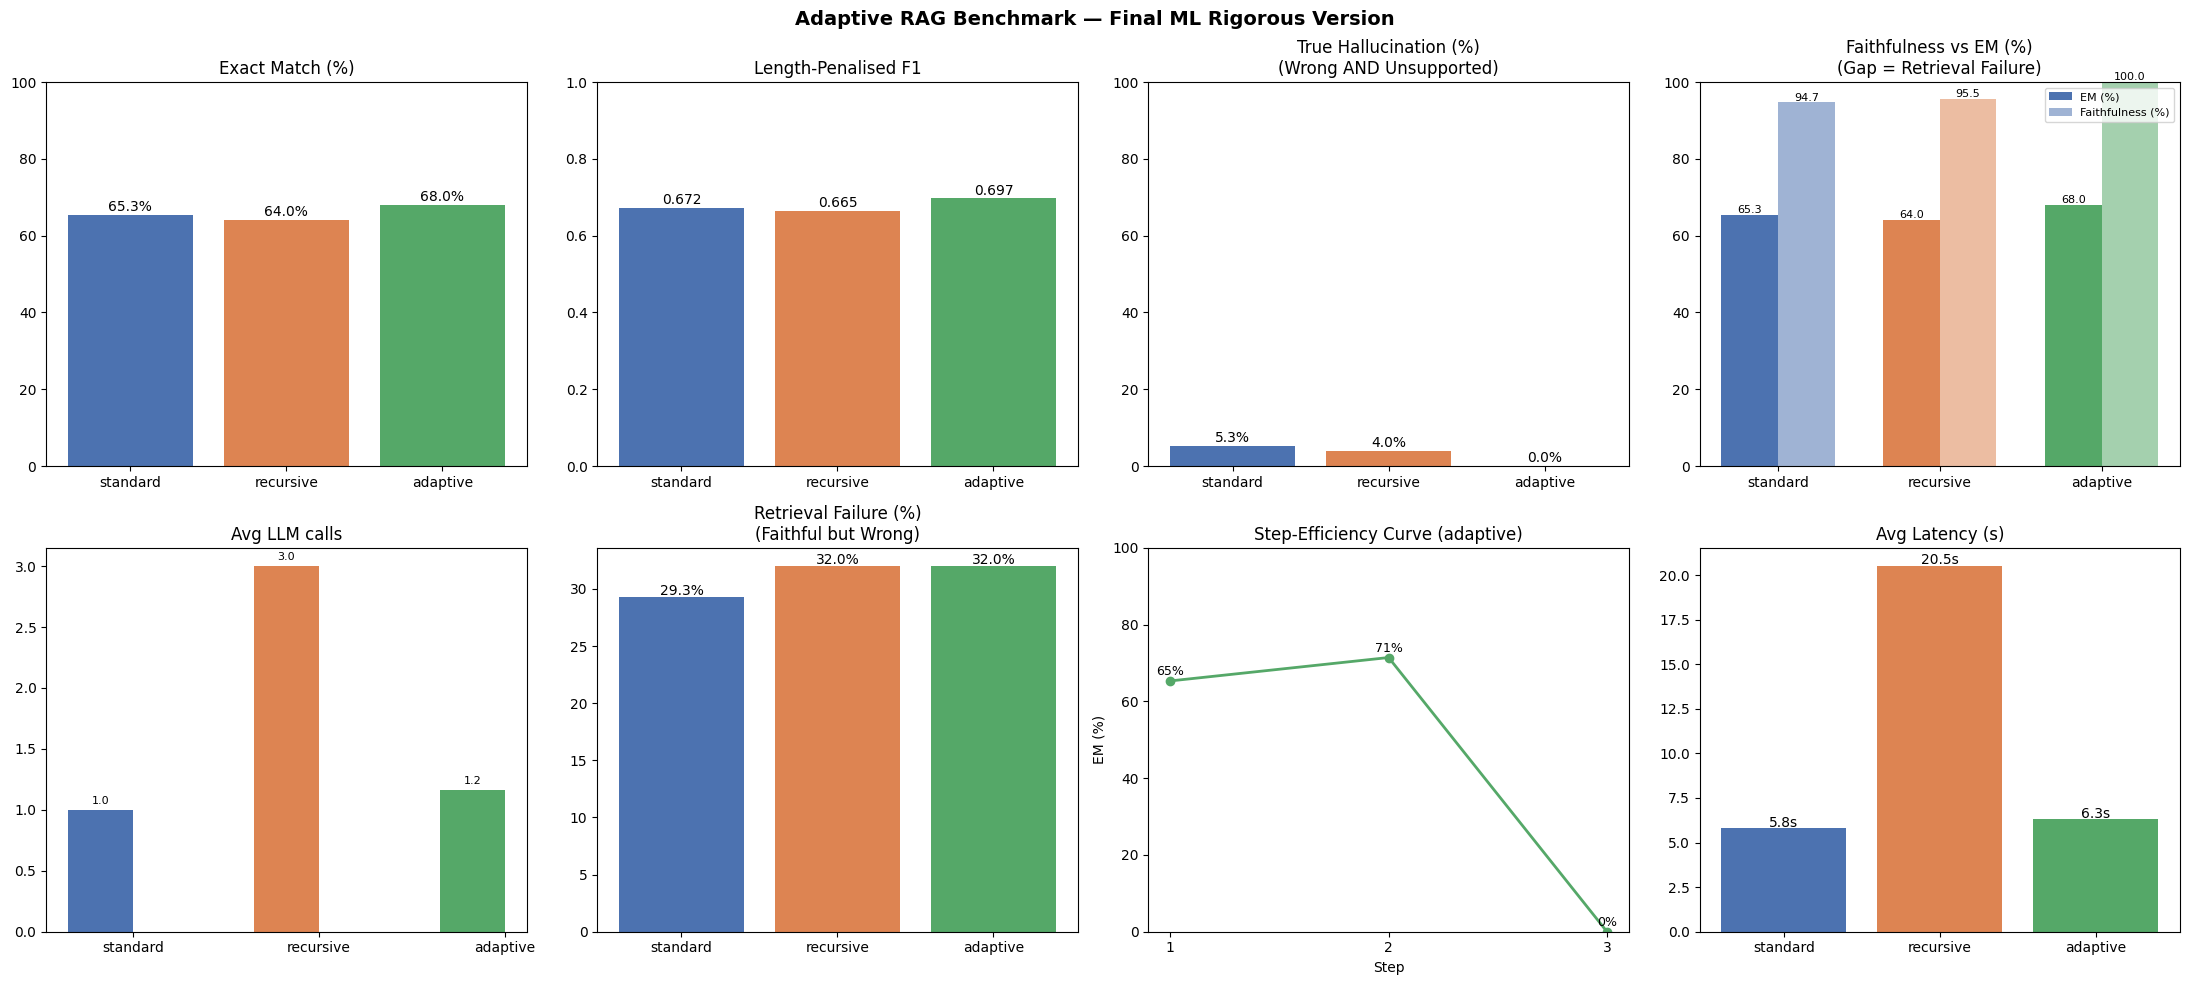

In [17]:
modes  = df_summary["Mode"].tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Adaptive RAG Benchmark — Final ML Rigorous Version", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.bar(modes, df_summary["EM (%)"], color=colors)
ax.set_title("Exact Match (%)")
ax.set_ylim(0, 100)
for i, v in enumerate(df_summary["EM (%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

ax = axes[0, 1]
ax.bar(modes, df_summary["F1 (len-penalised)"], color=colors)
ax.set_title("Length-Penalised F1")
ax.set_ylim(0, 1.0)
for i, v in enumerate(df_summary["F1 (len-penalised)"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

ax = axes[0, 2]
ax.bar(modes, df_summary["True Hallucination (%)"], color=colors)
ax.set_title("True Hallucination (%)\n(Wrong AND Unsupported)")
ax.set_ylim(0, 100)
for i, v in enumerate(df_summary["True Hallucination (%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

ax = axes[0, 3]
x = np.arange(len(modes))
width = 0.35
b1 = ax.bar(x - width/2, df_summary["EM (%)"], width, label="EM (%)", color=colors)
b2 = ax.bar(x + width/2, df_summary["Faithfulness (%)"], width, label="Faithfulness (%)", color=["#4C72B088","#DD845288","#55A86888"])
ax.set_title("Faithfulness vs EM (%)\n(Gap = Retrieval Failure)")
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend(fontsize=8)
ax.set_ylim(0, 100)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{bar.get_height():.1f}", ha="center", fontsize=8)

ax = axes[1, 0]
b1 = ax.bar(x - width/2, df_summary["Avg LLM Calls (all)"], width, label="All Qs", color=colors)
ax.set_title("Avg LLM calls")
ax.set_xticks(x)
ax.set_xticklabels(modes)
for bar in list(b1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{bar.get_height():.1f}", ha="center", fontsize=8)

ax = axes[1, 1]
ax.bar(modes, df_summary["Retrieval Fail (%)"], color=colors)
ax.set_title("Retrieval Failure (%)\n(Faithful but Wrong)")
for i, v in enumerate(df_summary["Retrieval Fail (%)"]):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=10)

ax = axes[1, 2]
adaptive_rs = results["adaptive"]
max_steps_seen = max(r["steps"] for r in adaptive_rs)
step_ems, step_ns = [], []
for depth in range(1, max_steps_seen + 1):
    at_depth = [r for r in adaptive_rs if r["steps"] >= depth and not r["abstained"]]
    if at_depth:
        correct_at = sum(1 for r in at_depth if len(r.get("step_correct", [])) >= depth and r["step_correct"][depth - 1])
        step_ems.append(correct_at / len(at_depth) * 100)
        step_ns.append(len(at_depth))
    else:
        step_ems.append(0.0)
        step_ns.append(0)
ax.plot(range(1, max_steps_seen + 1), step_ems, marker="o", color="#55A868", linewidth=2)
ax.set_title("Step-Efficiency Curve (adaptive)")
ax.set_xlabel("Step")
ax.set_ylabel("EM (%)")
ax.set_ylim(0, 100)
ax.set_xticks(range(1, max_steps_seen + 1))
for i, (v, n) in enumerate(zip(step_ems, step_ns)):
    ax.text(i + 1, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

ax = axes[1, 3]
ax.bar(modes, df_summary["Avg Latency (s)"], color=colors)
ax.set_title("Avg Latency (s)")
for i, v in enumerate(df_summary["Avg Latency (s)"]):
    ax.text(i, v + 0.1, f"{v:.1f}s", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/benchmark_final_parity.png", dpi=150, bbox_inches="tight")
plt.show()
